## Análise de hábitos e notas de estudantes
Notebook criado para realizar analises e previsoes de notas em exames escolares com base em **hábitos** e **caracteristicas** de estudantes
- Bibliotecas utilizadas: Pandas e Seaborn.

Realizando as importações das bibliotecas necessarias e , logo em seguida, coloquei um nome para cada uma delas.

In [1]:
import pandas as pd
import seaborn as sns

## Busca a planilha/dados para podermos analisar

In [7]:
df = pd.read_csv(r".\data\dataset_aula03_student_habits_performance.csv")

### Exibe os 5 primeiros

In [8]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


### Exibe os 5 ultimos

In [9]:
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


### Exibe principais informações sobre a planilha/dados analisados

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [18]:
df["parental_education_level"].isna().sum()

np.int64(0)

In [19]:
df["parental_education_level"].notnull().sum()

np.int64(1000)

In [17]:
df["parental_education_level"] = df["parental_education_level"].fillna("Desconhecido")

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

### Opções unicas dentro da opção "Nivel de escolaridade dos pais"

In [21]:
df["parental_education_level"].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Desconhecido']
Length: 4, dtype: str

In [22]:
df["parental_education_level"].nunique()

4

In [23]:
colunas = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

<Axes: >

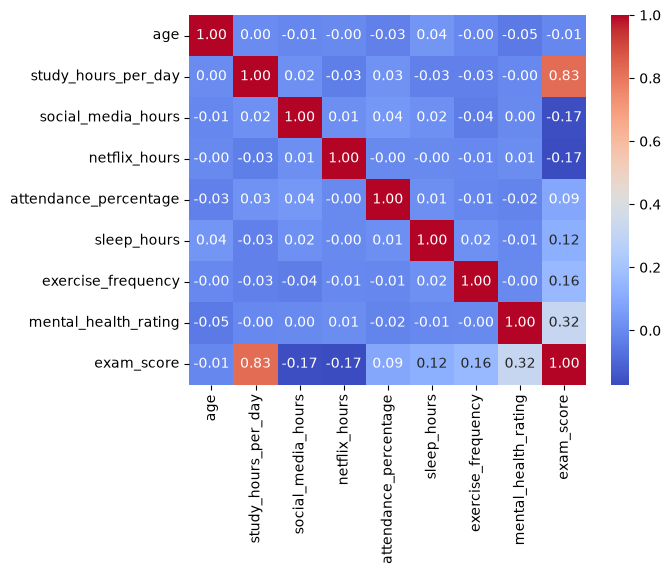

In [26]:
sns.heatmap(data=df[colunas].corr(), annot=True, cmap="coolwarm",fmt=".2f")

### Grafico horas de Estudo x Nota no exame

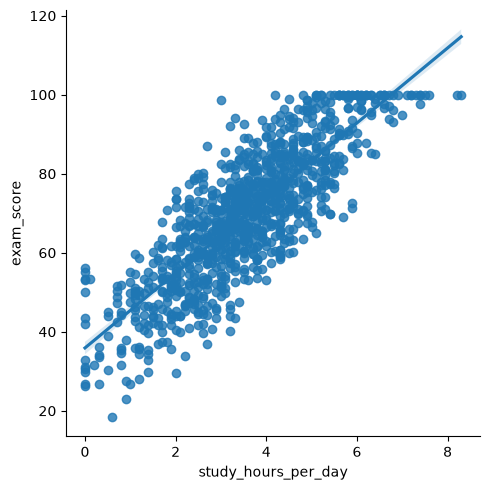

In [29]:
sns.lmplot(data=df,x="study_hours_per_day",y="exam_score");

### Relação horas de Netflix e Nota no exame

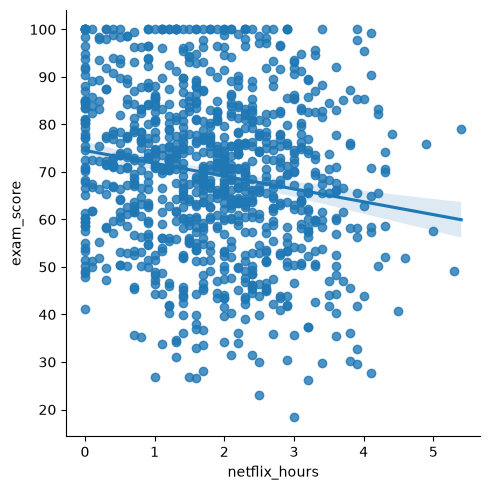

In [30]:
sns.lmplot(data=df,x="netflix_hours",y="exam_score");

### Filtro de horas, altas e baixas que denota a importancia de horas de estudo, quanto maior a nota maior as horas de estudo

In [35]:
filtro_horas_altas = df["study_hours_per_day"] >= 5
filtro_horas_baixas = df["study_hours_per_day"] < 2

media_alta = df[filtro_horas_altas]["exam_score"].mean()
media_baixa = df[filtro_horas_baixas]["exam_score"].mean()

print(f"A media das pessoas que estudaram 5 ou mais horas foi:{media_alta:.2f}. ja a media das pessoas que estudaram menos de duas horas foi:{media_baixa:.2f}")

A media das pessoas que estudaram 5 ou mais horas foi:90.30. ja a media das pessoas que estudaram menos de duas horas foi:45.56


### Separar a base para download

In [36]:
df.to_csv("base_estudantes_tratado.csv")